In [3]:
from deepface import DeepFace
import os
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide tensorflow logs

In [5]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Virat Kohli.jpg"

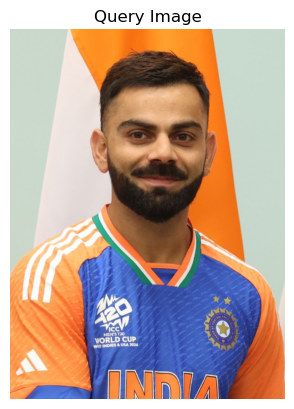

In [6]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [7]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="Facenet",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-10 12:42:11 - Searching test_image/Virat Kohli.jpg in 38 length datastore
26-02-10 12:42:16 - find function duration 27.02760887145996 seconds


In [8]:
threshold = 0.28  # FaceNet threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Match found: Virat Kohli
Score: 0.93


In [9]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Stranger.jpg"

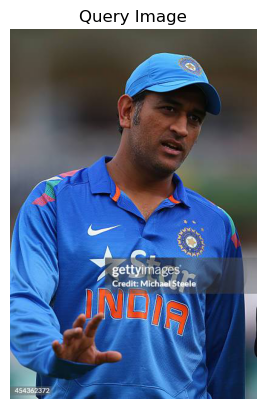

In [10]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [11]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="Facenet",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-10 12:42:54 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 12:42:54 - find function duration 13.692398071289062 seconds


In [12]:
threshold = 0.28  # FaceNet threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Stranger detected


In [13]:
test_data = {}

for file in os.listdir("test_image"):
    if file.lower().endswith((".jpg", ".jpeg", ".png",".jpe")):
        name = os.path.splitext(file)[0]
        test_data[name] = f"test_image/{file}"

print(test_data)


{'Droupadi Murmu': 'test_image/Droupadi Murmu.jpg', 'Kiran Dutta': 'test_image/Kiran Dutta.png', 'PM Modi': 'test_image/PM Modi.jpg', 'Shreya Ghoshal': 'test_image/Shreya Ghoshal.jpg', 'Stranger': 'test_image/Stranger.jpg', 'Stranger1': 'test_image/Stranger1.jpg', 'Stranger2': 'test_image/Stranger2.jpg', 'Stranger3': 'test_image/Stranger3.jpg', 'Stranger4': 'test_image/Stranger4.jpg', 'Virat kohli': 'test_image/Virat kohli.jpg'}


In [14]:
DB_PATH = "database"
TEST_IMAGE = "test_image/Kiran Dutta.png"

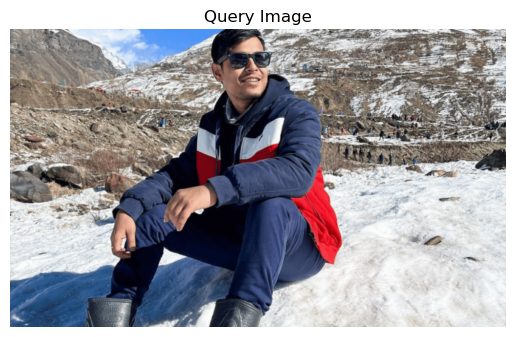

In [15]:
img = Image.open(TEST_IMAGE)
plt.imshow(img)
plt.axis("off")
plt.title("Query Image")
plt.show()

In [16]:
results = DeepFace.find(
    img_path=TEST_IMAGE,
    db_path="database",
    model_name="Facenet",
    detector_backend="retinaface",
    enforce_detection=False
)

26-02-10 13:03:59 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 13:04:00 - find function duration 15.448872327804565 seconds


In [17]:
threshold = 0.28  # FaceNet threshold
df = results[0]

if df.empty:
    print("Stranger detected")

else:
    best = df.iloc[0]
    distance = best["distance"]

    if distance < threshold:
        identity = best["identity"]
        person = os.path.basename(os.path.dirname(identity))
        confidence = round(1 - distance, 3)

        print("Match found:", person)
        print("Score:", confidence)

    else:
        print("Stranger detected")


Match found: Kiran Dutta
Score: 0.93


In [17]:
correct = 0
total = 0
threshold = 0.28

known_people = set(os.listdir("database"))  

for label, img in test_data.items():

    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="Facenet",
        detector_backend="retinaface",
        enforce_detection=False
    )

    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]

        if distance < threshold:
            predicted = os.path.basename(os.path.dirname(best["identity"]))
        else:
            predicted = "stranger"

    print(f"True: {label} | Predicted: {predicted}")

    # normalize label
    true_label = label if label in known_people else "stranger"

    if predicted == true_label:
        correct += 1

    total += 1

accuracy = correct / total
print("\nAccuracy:", round(accuracy * 100, 2), "%")


26-02-10 13:04:17 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 13:04:18 - find function duration 15.920883655548096 seconds
True: Droupadi Murmu | Predicted: Droupadi Murmu
26-02-10 13:04:32 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 13:04:32 - find function duration 13.707570791244507 seconds
True: Kiran Dutta | Predicted: Kiran Dutta
26-02-10 13:04:44 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 13:04:44 - find function duration 12.263625144958496 seconds
True: PM Modi | Predicted: PM Modi
26-02-10 13:04:58 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 13:04:58 - find function duration 13.744664192199707 seconds
True: Shreya Ghoshal | Predicted: Shreya Ghoshal
26-02-10 13:05:12 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 13:05:12 - find function duration 14.130661964416504 seconds
True: Stranger | Predicted: stranger
26-02-10 13:05:23 - Searching test_ima

In [19]:
# FAR: stranger predicted as known
false_accept = 0
total_stranger = 0

for label, img in test_data.items():
    true_label = label if label in known_people else "stranger"
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name="Facenet",
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    if true_label == "stranger":
        total_stranger += 1
        if predicted != "stranger":
            false_accept += 1

far = false_accept / total_stranger if total_stranger > 0 else 0
print("False Acceptance Rate (FAR):", round(far * 100, 2), "%")


26-02-09 23:18:30 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 23:18:31 - find function duration 14.178382158279419 seconds
26-02-09 23:18:43 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 23:18:44 - find function duration 13.072153091430664 seconds
26-02-09 23:18:55 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 23:18:56 - find function duration 12.064743280410767 seconds
26-02-09 23:19:08 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 23:19:08 - find function duration 12.37798261642456 seconds
26-02-09 23:19:20 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 23:19:21 - find function duration 12.376042127609253 seconds
26-02-09 23:19:31 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-09 23:19:32 - find function duration 11.063081741333008 seconds
26-02-09 23:19:43 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-09 23:19:43 - find f

In [19]:
# FRR: known person predicted as stranger
false_reject = 0
total_known = 0

for label, img in test_data.items():
    true_label = label if label in known_people else "stranger"
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name='Facenet',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    if true_label != "stranger":
        total_known += 1
        if predicted == "stranger":
            false_reject += 1

frr = false_reject / total_known if total_known > 0 else 0
print("False Rejection Rate (FRR):", round(frr * 100, 2), "%")

26-02-10 13:08:32 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-10 13:08:33 - find function duration 16.07511830329895 seconds
26-02-10 13:08:49 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-10 13:08:50 - find function duration 17.110864877700806 seconds
26-02-10 13:09:03 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-10 13:09:04 - find function duration 14.221051454544067 seconds
26-02-10 13:09:17 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-10 13:09:18 - find function duration 13.772550106048584 seconds
26-02-10 13:09:30 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-10 13:09:30 - find function duration 12.46806001663208 seconds
26-02-10 13:09:41 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-10 13:09:41 - find function duration 11.111786842346191 seconds
26-02-10 13:09:54 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-10 13:09:54 - find fu

26-02-09 23:24:07 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 23:24:08 - find function duration 14.828458309173584 seconds
26-02-09 23:24:21 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 23:24:21 - find function duration 13.110158205032349 seconds
26-02-09 23:24:32 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 23:24:32 - find function duration 11.222851991653442 seconds
26-02-09 23:24:45 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 23:24:46 - find function duration 13.131045818328857 seconds
26-02-09 23:24:59 - Searching test_image/Stranger.jpg in 38 length datastore
26-02-09 23:24:59 - find function duration 13.970771789550781 seconds
26-02-09 23:25:10 - Searching test_image/Stranger1.jpg in 38 length datastore
26-02-09 23:25:11 - find function duration 11.208332538604736 seconds
26-02-09 23:25:22 - Searching test_image/Stranger2.jpg in 38 length datastore
26-02-09 23:25:22 - find 

<Figure size 1200x800 with 0 Axes>

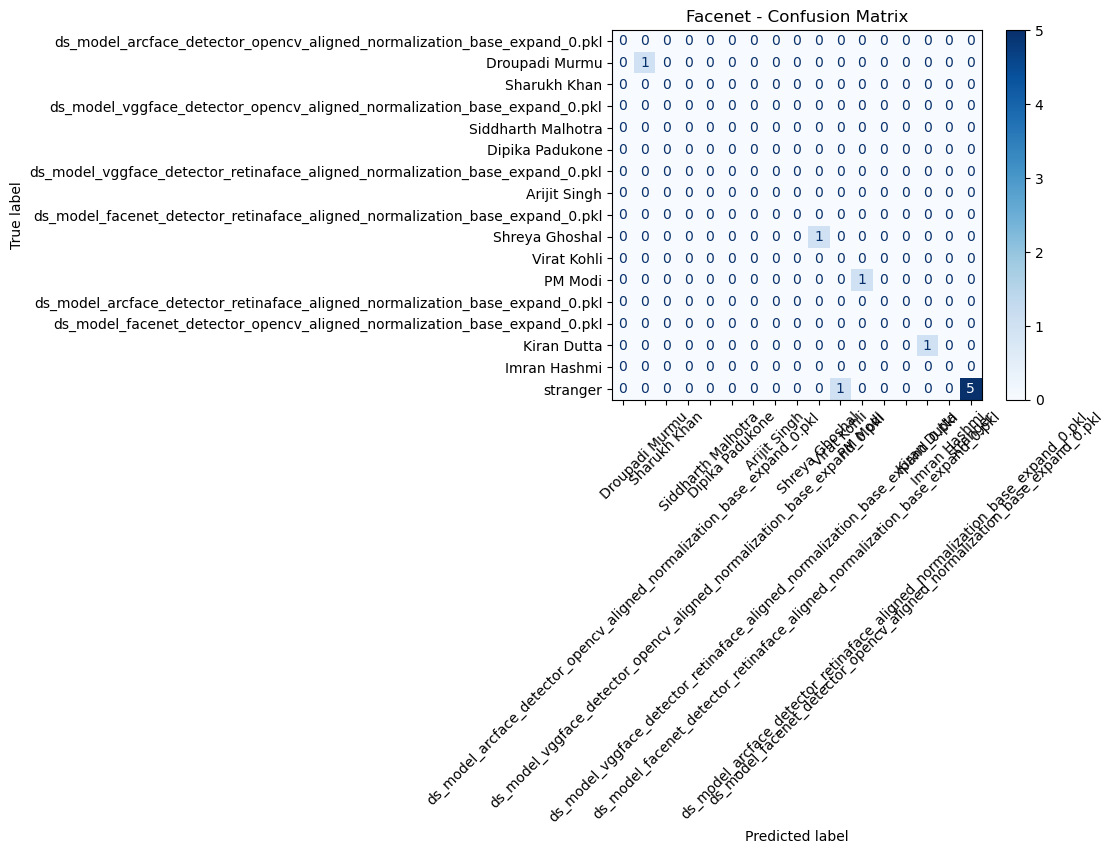

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_name = "Facenet"
threshold = 0.28

y_true = []
y_pred = []

known_people = set(os.listdir("database"))

for label, img_path in test_data.items():
    results = DeepFace.find(
        img_path=img_path,
        db_path="database",
        model_name='Facenet',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        predicted = "stranger"
    else:
        best = df.iloc[0]
        distance = best["distance"]
        predicted = os.path.basename(os.path.dirname(best["identity"])) if distance < threshold else "stranger"

    true_label = label if label in known_people else "stranger"

    y_true.append(true_label)
    y_pred.append(predicted)

labels = list(known_people) + ["stranger"]
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(12,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title(f"{model_name} - Confusion Matrix")
plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np

model_name = "Facnet"
threshold = 0.28

known_distances = []
stranger_distances = []

for label, img in test_data.items():
    results = DeepFace.find(
        img_path=img,
        db_path="database",
        model_name='Facenet',
        detector_backend="retinaface",
        enforce_detection=False
    )
    df = results[0]

    if df.empty:
        distance = 1.0  # large distance for stranger
    else:
        distance = df.iloc[0]["distance"]

    if label in os.listdir("database"):
        known_distances.append(distance)
    else:
        stranger_distances.append(distance)

plt.figure(figsize=(10,6))

plt.hist(known_distances, bins=10, alpha=0.8, label="Known", color="blue")
plt.hist(stranger_distances, bins=10, alpha=0.5, label="Stranger", color="orange")

plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.title("VGG-Face - Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()


NameError: name 'test_data' is not defined

In [23]:
from deepface import DeepFace
import time

test_images = {
    'Droupadi Murmu': 'test_image/Droupadi Murmu.jpg',
    'Kiran Dutta': 'test_image/Kiran Dutta.png',
    'PM Modi': 'test_image/PM Modi.jpg',
    'Shreya Ghoshal': 'test_image/Shreya Ghoshal.jpg',
    'Stranger': 'test_image/Stranger.jpg',
    'Stranger1': 'test_image/Stranger1.jpg',
    'Stranger2': 'test_image/Stranger2.jpg',
    'Stranger3': 'test_image/Stranger3.jpg',
    'Stranger4': 'test_image/Stranger4.jpg',
    'Virat kohli': 'test_image/Virat kohli.jpg'
}

db_path = "database"  # your database folder

inference_times = []

# Optional warm-up
_ = DeepFace.find(img_path=list(test_images.values())[0],
                  db_path=db_path,
                  model_name="Facenet",  # or current model
                  detector_backend="retinaface",
                  enforce_detection=False)

for name, img_path in test_images.items():
    start_time = time.time()
    _ = DeepFace.find(img_path=img_path,
                      db_path=db_path,
                      model_name="Facenet",  # or current model
                      detector_backend="retinaface",
                      enforce_detection=False)
    end_time = time.time()
    t = end_time - start_time
    inference_times.append(t)
    print(f"Inference time for {name}: {t:.4f} sec")

avg_time = sum(inference_times) / len(inference_times)
print(f"\nAverage inference time for this model: {avg_time:.4f} sec")


26-02-09 23:36:33 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 23:36:34 - find function duration 15.622231721878052 seconds
26-02-09 23:36:49 - Searching test_image/Droupadi Murmu.jpg in 38 length datastore
26-02-09 23:36:49 - find function duration 15.017988204956055 seconds
Inference time for Droupadi Murmu: 15.0185 sec
26-02-09 23:37:03 - Searching test_image/Kiran Dutta.png in 38 length datastore
26-02-09 23:37:03 - find function duration 13.467261552810669 seconds
Inference time for Kiran Dutta: 13.4677 sec
26-02-09 23:37:15 - Searching test_image/PM Modi.jpg in 38 length datastore
26-02-09 23:37:15 - find function duration 12.126569271087646 seconds
Inference time for PM Modi: 12.1288 sec
26-02-09 23:37:27 - Searching test_image/Shreya Ghoshal.jpg in 38 length datastore
26-02-09 23:37:28 - find function duration 12.593557834625244 seconds
Inference time for Shreya Ghoshal: 12.5938 sec
26-02-09 23:37:39 - Searching test_image/Stranger.jpg in 38 length 